## Загрузка данных и первичный осмотр

In [1]:
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

projectPath = Path().resolve().parent
dataPath = projectPath / "data" / "Customer-Churn-Records.csv"


df = pd.read_csv(dataPath)

In [2]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## Базовый контроль качества

In [5]:
df.isna().mean()*100

RowNumber             0.0
CustomerId            0.0
Surname               0.0
CreditScore           0.0
Geography             0.0
Gender                0.0
Age                   0.0
Tenure                0.0
Balance               0.0
NumOfProducts         0.0
HasCrCard             0.0
IsActiveMember        0.0
EstimatedSalary       0.0
Exited                0.0
Complain              0.0
Satisfaction Score    0.0
Card Type             0.0
Point Earned          0.0
dtype: float64

In [6]:
duplicates = df[df.duplicated(keep=False)]
duplicates

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned


In [7]:
print(df[(df["Age"]<0) | (df["Age"]>110)]) # выводим строки с не реальным возрастом
print("-"*50)
print(df[(df["Balance"]<0)]) # выводим строки с отрицательным балансом
print("-"*50)

Empty DataFrame
Columns: [RowNumber, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited, Complain, Satisfaction Score, Card Type, Point Earned]
Index: []
--------------------------------------------------
Empty DataFrame
Columns: [RowNumber, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited, Complain, Satisfaction Score, Card Type, Point Earned]
Index: []
--------------------------------------------------


Проблем никаких нет, значит ничего не нужно исправлять или исключать

По полученным данным можно сделать вывод что данные чистые - полные, уникальные, целые и валидные

## EDA

Посчитаем частоты для разных характеристик

In [8]:
cuted_age = pd.cut(df["Age"],4,labels=["Молодость","Средний возраст","Пожилой возраст","Старческий возраст"],include_lowest=True)
print(cuted_age.value_counts())
print("-"*50)
print(df["Gender"].value_counts())
print("-"*50)
print(df["Geography"].value_counts())
print("-"*50)


Age
Молодость             4609
Средний возраст       4591
Пожилой возраст        728
Старческий возраст      72
Name: count, dtype: int64
--------------------------------------------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
--------------------------------------------------
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
--------------------------------------------------


In [9]:
print(df["Card Type"].value_counts())
print("-"*50)
print(df["NumOfProducts"].value_counts())

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64
--------------------------------------------------
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


Выведем средний доход по каждой стране

In [10]:
print(df.groupby("Geography")["EstimatedSalary"].mean())

Geography
France      99899.180814
Germany    101113.435102
Spain       99440.572281
Name: EstimatedSalary, dtype: float64


Выведем распределение таргета

In [11]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

Теперь сделаем матрицу корреляции признаков, чтобы выяснить не являются ли какие-то признаки утечкой данных таргета

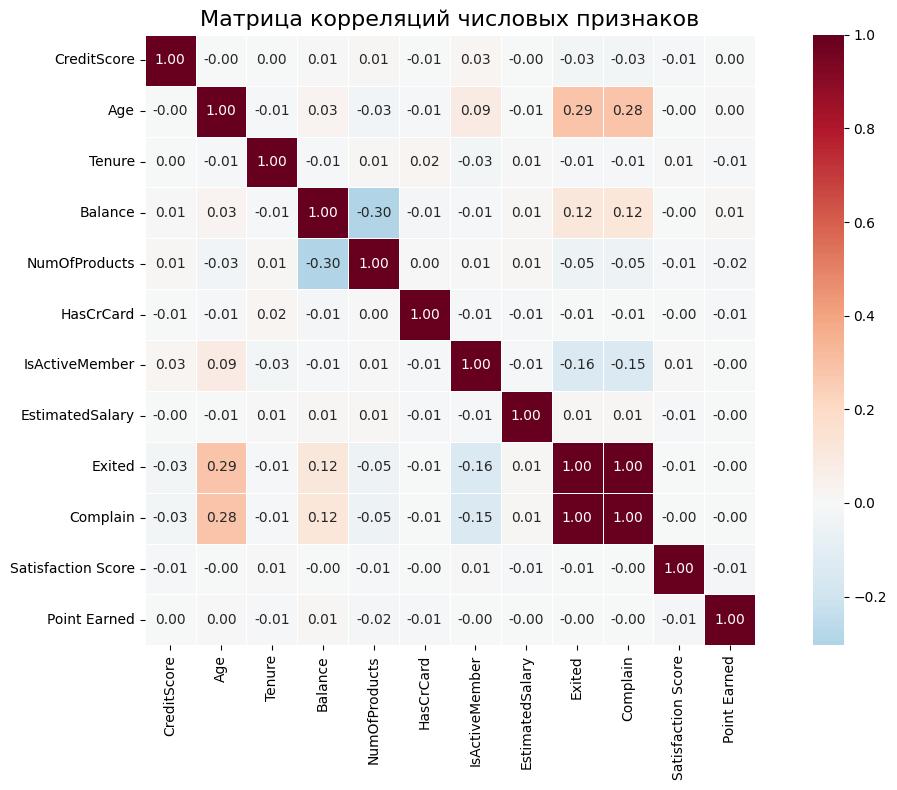

In [12]:
numeric_cols = df.select_dtypes(["int64","float64"]).columns.to_list()
numeric_cols = [col for col in numeric_cols if col not in ["RowNumber","CustomerId"]]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True,           # цифры в клетках
            fmt='.2f',            # формат чисел
            cmap='RdBu_r',        
            center=0,             # центр цветовой шкалы в 0
            square=True,          # квадратные клетки
            linewidths=0.5)       # разделительные линии
plt.title('Матрица корреляций числовых признаков', fontsize=16)
plt.tight_layout()
plt.savefig('artifacts/figures/correlation_matrix.png')
plt.show()

In [13]:
print("Связь Complain c Exited:")
print(pd.crosstab(df['Complain'], df['Exited'], margins=True))

print("\n Связь Satisfaction Score c Exited:")
print(pd.crosstab(df['Satisfaction Score'], df['Exited'], margins=True))

Связь Complain c Exited:
Exited       0     1    All
Complain                   
0         7952     4   7956
1           10  2034   2044
All       7962  2038  10000

 Связь Satisfaction Score c Exited:
Exited                 0     1    All
Satisfaction Score                   
1                   1545   387   1932
2                   1575   439   2014
3                   1641   401   2042
4                   1594   414   2008
5                   1607   397   2004
All                 7962  2038  10000


Прямо выясняется, что корреляция Complain с таргетом почти 1.00, соответственно добавив его в признаки мы получаем прямую утечку данных

С Satisfaction Score все сложнее - выясняется что его распределение напрямую связанно с жалобой (а также с распределением таргета), соответственно есть большой шанс утечки данных, этот признак мы тоже будем исключать при обучении

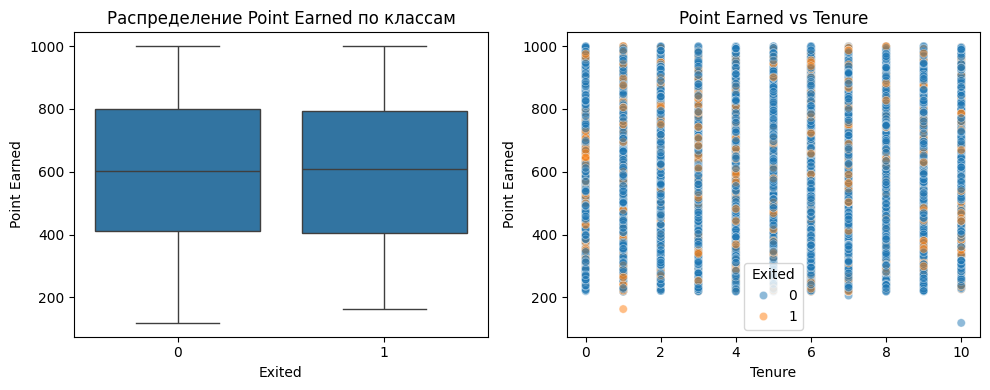

In [14]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Exited', y='Point Earned', data=df)
plt.title('Распределение Point Earned по классам')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Tenure', y='Point Earned', hue='Exited', data=df, alpha=0.5)
plt.title('Point Earned vs Tenure')
plt.tight_layout()
plt.show()

Есть подозрение что Point Earned может выдаваться постфактум и их значение на момент прогноза может быть неактуальным. Нет прямой зависимости от Tenure, поэтому для исключения возможных проблем с временными сдвигами в данных исключим этот признак при обучении, тем более он имеет почти нулевую корреляцию с таргетом, а распределение баллов между ушедшими и оставшимися практически одинаковые/

**Итоги EDA:**
- Все предложенные данные примерно в равных пропорциях, но больше всего преобладают молодые-средние по возрасту люди, а также люди из Франции
- Есть признаки которые сильно коррелируют с таргетом, вследствие чего может произойти утечка данных
- Таргет распределен 80/20, соответственно при обучении нужно будет смотреть на ROC_AUC, а не на accuracy

## Визуализация данных

Построим график распределения возраста людей

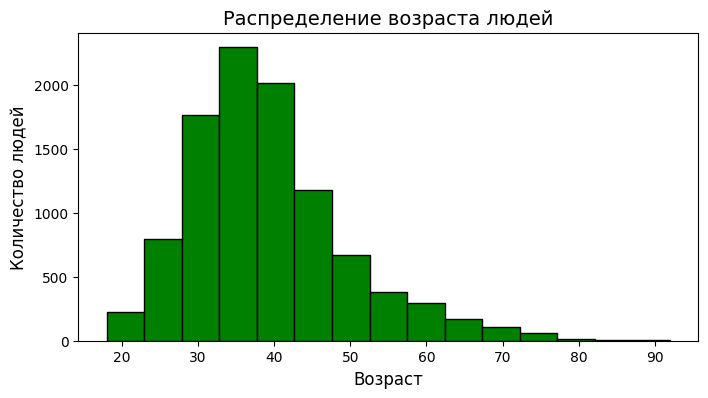

In [15]:
fig,ax = plt.subplots(figsize=(8,4))
n_bins = int(np.ceil(np.log2(len(df)))+1) # формула для расчета оптимального количества bin
ax.hist(df["Age"],bins=n_bins,color="g",edgecolor="black")
ax.set_xlabel("Возраст",fontsize=12)
ax.set_ylabel("Количество людей",fontsize=12)
ax.set_title("Распределение возраста людей",fontsize=14)
plt.savefig('artifacts/figures/age_histogram.png')
plt.show()

Также построим график распределения дохода по странам

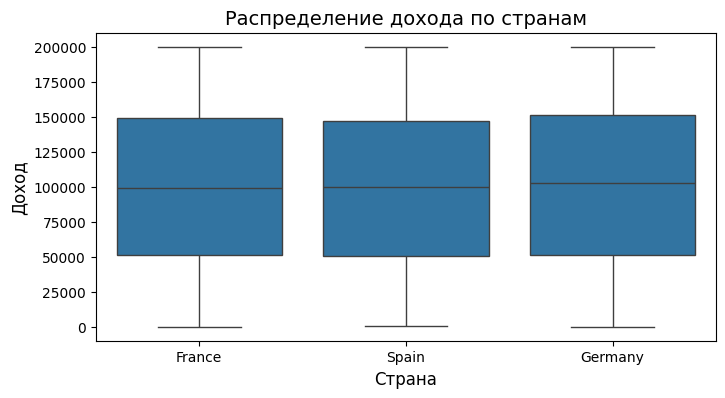

In [16]:
fig,ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df,x='Geography',y='EstimatedSalary',ax=ax)
ax.set_xlabel("Страна",fontsize=12)
ax.set_ylabel("Доход",fontsize=12)
ax.set_title("Распределение дохода по странам",fontsize=14)
plt.savefig('artifacts/figures/revenue_by_country_boxplot.png')
plt.show()

Построим диаграмму рассеивания распределения дохода от возраста людей

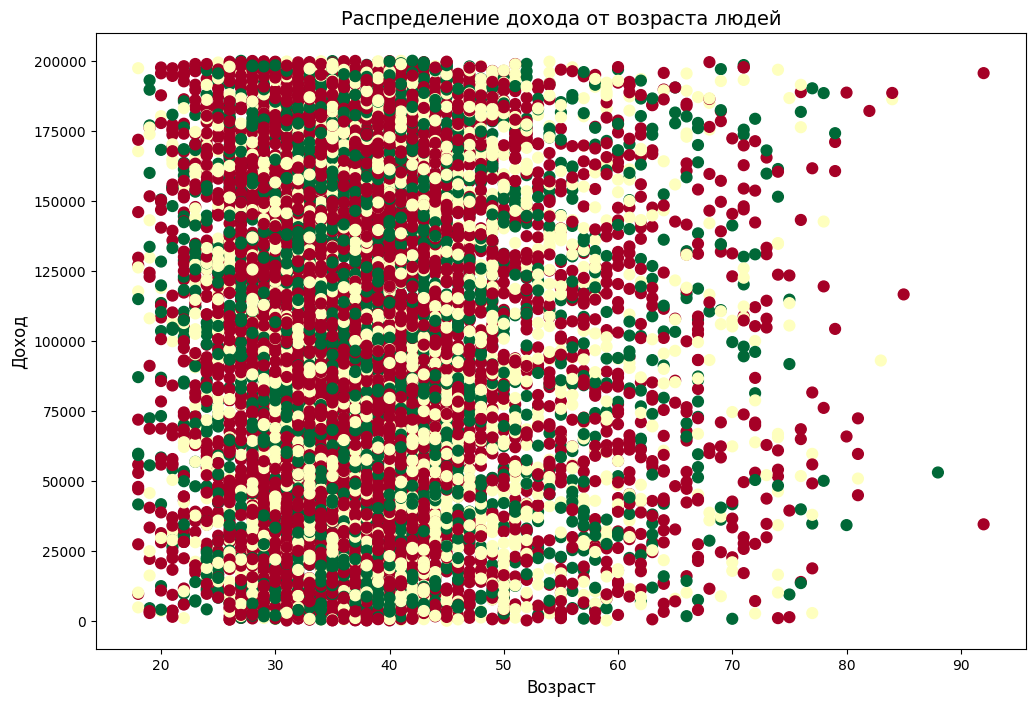

In [17]:
fig,ax = plt.subplots(figsize=(12,8))
country_codes = pd.Categorical(df["Geography"]).codes
scatter = ax.scatter(df['Age'],df["EstimatedSalary"],c = country_codes,cmap="RdYlGn",s=60)
ax.set_xlabel("Возраст",fontsize=12)
ax.set_ylabel("Доход",fontsize=12)
ax.set_title("Распределение дохода от возраста людей",fontsize=14)
plt.savefig('artifacts/figures/age_vs_revenue_scatter.png')
plt.show()

Дополнительно построим гистограмму количества продуктов банка у клиентов

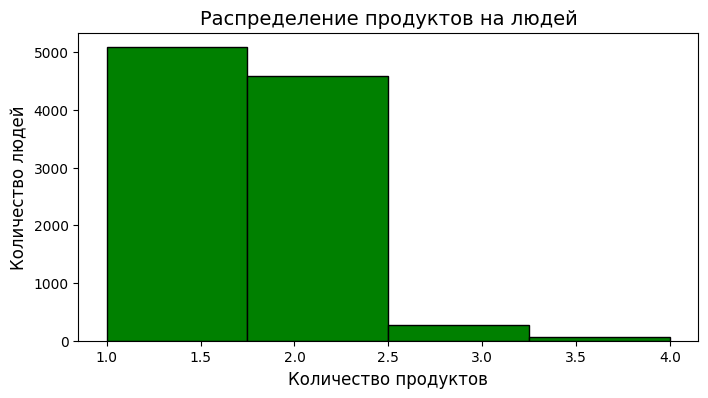

In [18]:
fig,ax = plt.subplots(figsize=(8,4))
n_bins = min(10,len(df["NumOfProducts"].unique())) #расчет оптимального количества bin
ax.hist(df["NumOfProducts"],bins=n_bins,color="g",edgecolor="black")
ax.set_xlabel("Количество продуктов",fontsize=12)
ax.set_ylabel("Количество людей",fontsize=12)
ax.set_title("Распределение продуктов на людей",fontsize=14)
plt.savefig('artifacts/figures/products_histogram.png')
plt.show()